
SIMON'S ALGORITHM - 3 BIT
Secret string: 110

Circuit
------------------------------------------------------------
     ┌───┐     ┌───┐          ┌─┐      
q_0: ┤ H ├──■──┤ H ├──────────┤M├──────
     ├───┤  │  └───┘     ┌───┐└╥┘   ┌─┐
q_1: ┤ H ├──┼─────────■──┤ H ├─╫────┤M├
     ├───┤  │         │  ├───┤ ║ ┌─┐└╥┘
q_2: ┤ H ├──┼────■────┼──┤ H ├─╫─┤M├─╫─
     └───┘┌─┴─┐  │  ┌─┴─┐└───┘ ║ └╥┘ ║ 
q_3: ─────┤ X ├──┼──┤ X ├──────╫──╫──╫─
          └───┘┌─┴─┐└───┘      ║  ║  ║ 
q_4: ──────────┤ X ├───────────╫──╫──╫─
               └───┘           ║  ║  ║ 
c: 3/══════════════════════════╩══╩══╩═
                               0  2  1 

MEASUREMENT RESULTS
000 : 234
011 : 262
100 : 283
111 : 221

INDEPENDENT EQUATIONS
1s0 + 1s1 = 0 (mod 2)
1s2 = 0 (mod 2)

Number of independent equations: 2
Required: 2


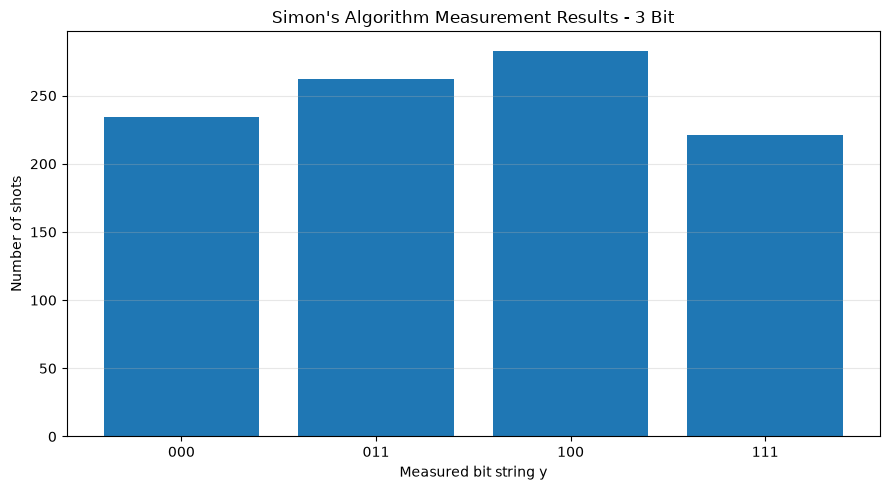

In [1]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots = 1000
secret = "110"
n = len(secret)

def orthogonal_basis(secret):
    s = [int(bit) for bit in secret]
    pivot = s.index(1)
    basis = []

    for j in range(n):
        if j == pivot:
            continue

        row = [0] * n

        if s[j] == 1:
            row[j] = 1
            row[pivot] = 1
        else:
            row[j] = 1

        basis.append(row)

    return basis

def create_simon_circuit(secret):
    n = len(secret)
    rows = orthogonal_basis(secret)
    m = len(rows)

    qc = QuantumCircuit(n + m, n)

    for q in range(n):
        qc.h(q)

    for output, row in enumerate(rows):
        for input_qubit in range(n):
            if row[input_qubit] == 1:
                qc.cx(input_qubit, n + output)

    for q in range(n):
        qc.h(q)

    qc.measure(range(n), range(n))

    return qc

def gf2_rank(rows, n):
    matrix = [row[:] for row in rows]
    rank = 0

    for col in range(n):
        pivot = None

        for r in range(rank, len(matrix)):
            if matrix[r][col] == 1:
                pivot = r
                break

        if pivot is None:
            continue

        matrix[rank], matrix[pivot] = matrix[pivot], matrix[rank]

        for r in range(len(matrix)):
            if r != rank and matrix[r][col] == 1:
                for c in range(col, n):
                    matrix[r][c] ^= matrix[rank][c]

        rank += 1

    return rank

qc = create_simon_circuit(secret)

print("\nSIMON'S ALGORITHM - 3 BIT")
print("=" * 60)
print("Secret string:", secret)
print("\nCircuit")
print("-" * 60)
print(qc.draw())

sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=shots
).result()

counts = result[0].data.c.get_counts()

print("\nMEASUREMENT RESULTS")
print("=" * 60)

for state, count in sorted(counts.items()):
    print(f"{state} : {count}")

equations = []

for state, count in counts.items():
    y = [int(bit) for bit in state[::-1]]

    if y == [0] * n:
        continue

    if gf2_rank(equations + [y], n) > gf2_rank(equations, n):
        equations.append(y)

    if len(equations) >= n - 1:
        break

print("\nINDEPENDENT EQUATIONS")
print("=" * 60)

for equation in equations:
    equation_string = " + ".join(
        f"{equation[i]}s{i}"
        for i in range(n)
        if equation[i] == 1
    )
    print(equation_string, "= 0 (mod 2)")

print("\nNumber of independent equations:", len(equations))
print("Required:", n - 1)

plt.figure(figsize=(9, 5))

states = list(counts.keys())
values = list(counts.values())

plt.bar(states, values)

plt.xlabel("Measured bit string y")
plt.ylabel("Number of shots")
plt.title("Simon's Algorithm Measurement Results - 3 Bit")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()